# **Notebook 2f: Evaluation of model 3 (100/50/30%)**

Evaluates the three RobBERT models with a proportion of weak labels using the test dataset.

## 1. Importing packages

In [ ]:
import os
import json
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

Mounted at /content/drive
Working dir: /content/drive/MyDrive/Individual thesis part/Model 3: handlabeled + weak_labels


## 2. Preparation

In [2]:
MODEL_DIR_100      = "./model_3_100"
MODEL_DIR_50      = "./model_3_50"
MODEL_DIR_30     = "./model_3_30"
TEST_DATA_PATH = "labeled_test.csv"
THRESHOLD_PATH_100 = "./model_3_100/threshold.json"
THRESHOLD_PATH_50 = "./model_3_50/threshold.json"
THRESHOLD_PATH_30 = "./model_3_50/threshold.json"
MODEL_NAME     = "pdelobelle/robbert-v2-dutch-base"
MAX_LENGTH     = 100
LABEL_COL      = "unnecessary"
SENT_COL       = "blurb_sent"
BATCH_SIZE     = 16

## 3. Loading data and model

In [3]:
# Loading test dataset
test_df = pd.read_csv(TEST_DATA_PATH)
drop_cols = [c for c in ["sent_position", "final_edit", "blurb"] if c in test_df.columns]
test_df = test_df.drop(columns=drop_cols)
print(f"Test: {len(test_df)} sentences, {test_df[LABEL_COL].mean():.1%} positive")

Test: 481 sentences, 23.1% positive


In [4]:
# Loading model and tokenizer
# Tokenizer is the same for all variants
tokenizer = AutoTokenizer.from_pretrained("pdelobelle/robbert-v2-dutch-base", use_fast=True)

# Loading models per variant
model_100 = AutoModelForSequenceClassification.from_pretrained("./model_3_100")
model_50  = AutoModelForSequenceClassification.from_pretrained("./model_3_50")
model_30  = AutoModelForSequenceClassification.from_pretrained("./model_3_30")
print("Models loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/733k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/383k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Models loaded


## 4. Generating test predictions

In [5]:
def tokenize(batch):
    return tokenizer(batch[SENT_COL], truncation=True, max_length=MAX_LENGTH)

def df_to_dataset(d):
    ds = Dataset.from_pandas(
        d[[SENT_COL, LABEL_COL]].rename(columns={LABEL_COL: "labels"}),
        preserve_index=False)
    return ds.map(tokenize, batched=True)

# Tokenize test data once
test_ds = df_to_dataset(test_df)
args = TrainingArguments(output_dir="./tmp_eval", per_device_eval_batch_size=BATCH_SIZE, report_to="none")

# Predictions per variant
results = {}
for name, model in [("100%", model_100), ("50%", model_50), ("30%", model_30)]:
    trainer = Trainer(model=model, args=args, data_collator=DataCollatorWithPadding(tokenizer))
    preds = trainer.predict(test_ds)
    probs = F.softmax(torch.tensor(preds.predictions), dim=-1).numpy()[:, 1]
    results[name] = {"probs": probs, "labels": preds.label_ids}
    print(f"Generated predictions for {name}: {len(probs)} sentences")

Map:   0%|          | 0/481 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Generated predictions for 100%: 481 sentences


Generated predictions for 50%: 481 sentences


Generated predictions for 30%: 481 sentences


In [6]:
# Loading thresholds per variant
thresholds = {}
for name, path in [("100%", "./model_3_100/threshold.json"),
                   ("50%",  "./model_3_50/threshold.json"),
                   ("30%",  "./model_3_30/threshold.json")]:
    with open(path) as f:
        thresholds[name] = json.load(f)["threshold"]
    print(f"Threshold {name}: {thresholds[name]}")

# Generating predictions per variant
for name in results:
    results[name]["preds"] = (results[name]["probs"] >= thresholds[name]).astype(int)
    test_sentences = test_df[SENT_COL].tolist()

Threshold 100%: 0.7200000000000002
Threshold 50%: 0.6300000000000001
Threshold 30%: 0.6600000000000001


In [7]:
# Saving test predictions
os.makedirs("test_predictions", exist_ok=True)

for name in results:
    np.save(f"./test_predictions/{name}_test_probs.npy", results[name]["probs"])
    np.save(f"./test_predictions/{name}_test_labels.npy", results[name]["labels"])

## 5. Evaluation


Model 3 — 100% weak labels (threshold=0.7200000000000002)
                 precision    recall  f1-score   support

  necessary (0)      0.905     0.900     0.902       370
unnecessary (1)      0.673     0.685     0.679       111

       accuracy                          0.850       481
      macro avg      0.789     0.792     0.791       481
   weighted avg      0.851     0.850     0.851       481

Macro F1 : 0.791
AUC      : 0.891


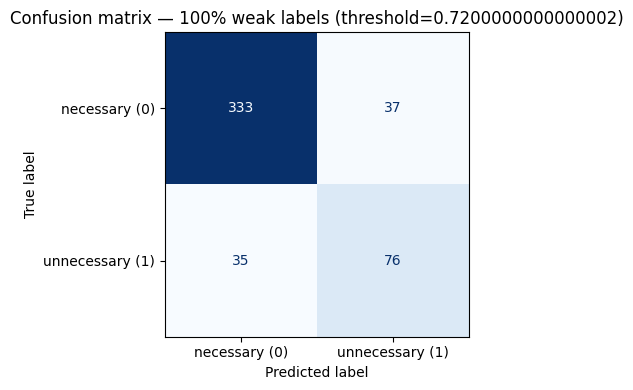

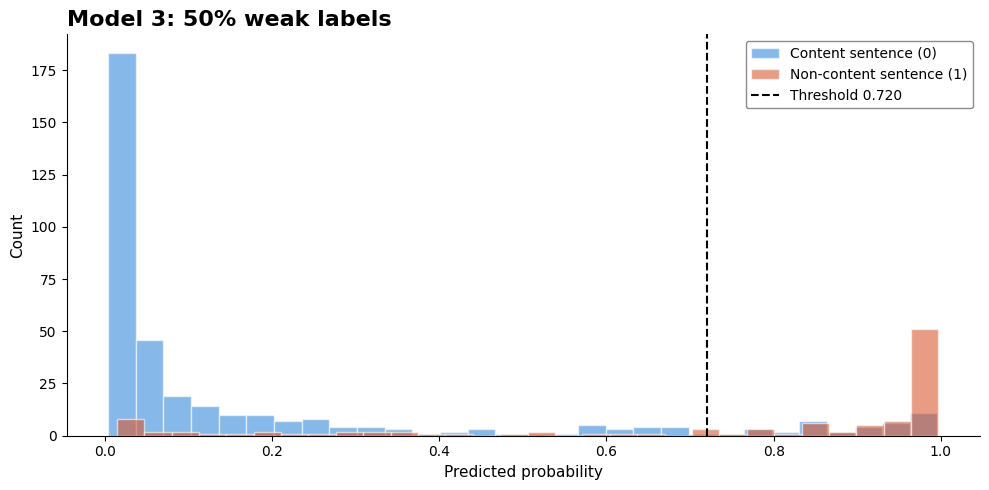


Model 3 — 50% weak labels (threshold=0.6300000000000001)
                 precision    recall  f1-score   support

  necessary (0)      0.907     0.900     0.904       370
unnecessary (1)      0.675     0.694     0.684       111

       accuracy                          0.852       481
      macro avg      0.791     0.797     0.794       481
   weighted avg      0.854     0.852     0.853       481

Macro F1 : 0.794
AUC      : 0.882


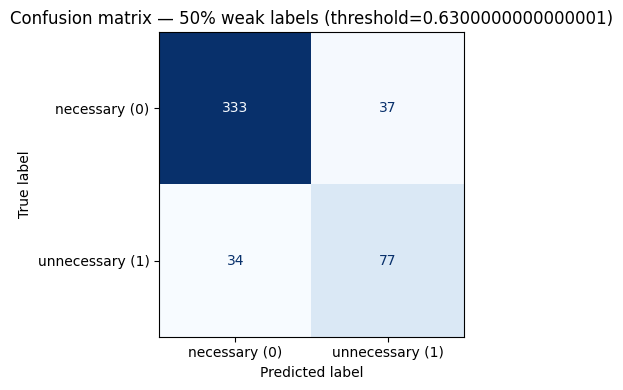

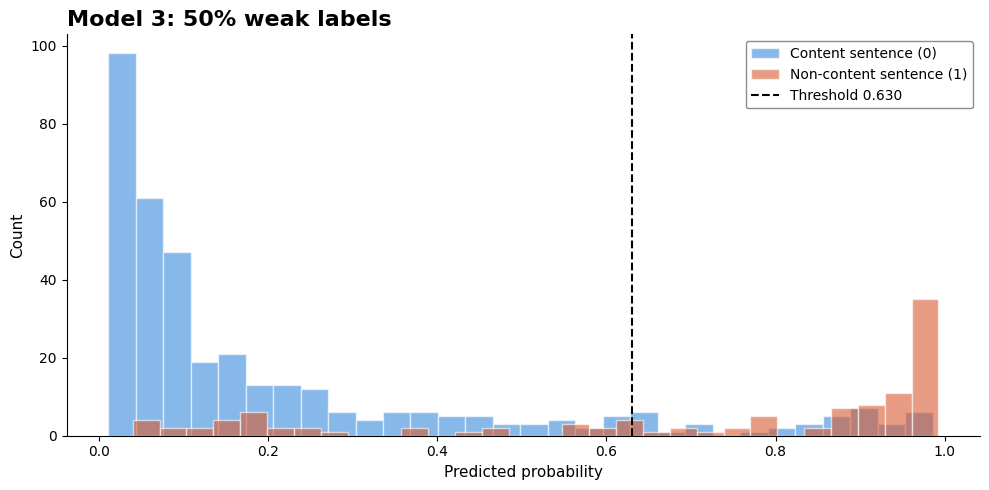


Model 3 — 30% weak labels (threshold=0.6600000000000001)
                 precision    recall  f1-score   support

  necessary (0)      0.888     0.924     0.906       370
unnecessary (1)      0.708     0.613     0.657       111

       accuracy                          0.852       481
      macro avg      0.798     0.768     0.781       481
   weighted avg      0.847     0.852     0.849       481

Macro F1 : 0.781
AUC      : 0.879


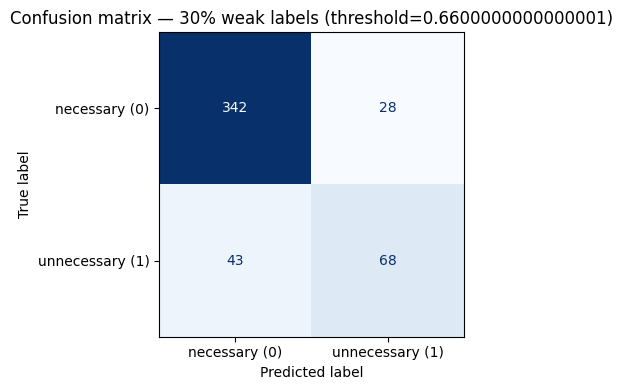

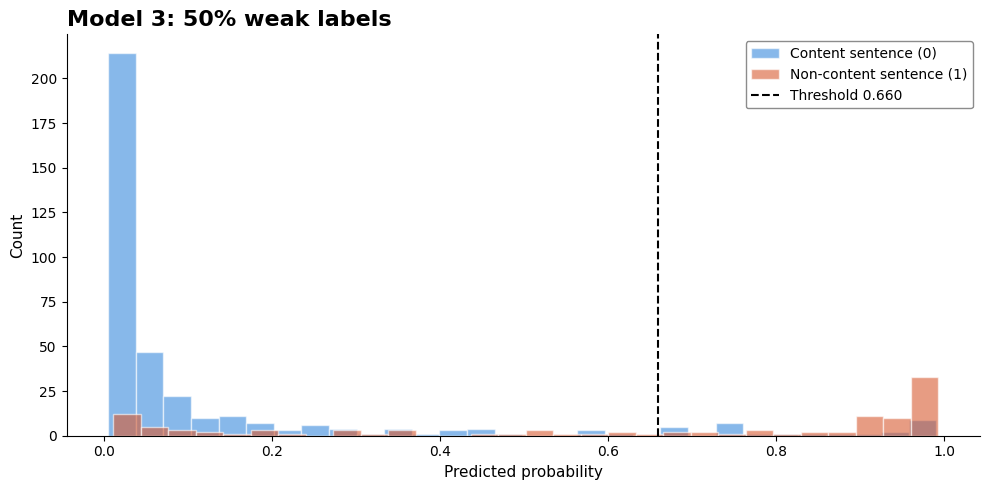

In [8]:
## Evaluation per variant
for name in ["100%", "50%", "30%"]:
    test_probs = results[name]["probs"]
    test_labels = results[name]["labels"]
    test_preds = results[name]["preds"]
    threshold = thresholds[name]

    print(f"\n{'='*50}")
    print(f"Model 3 — {name} weak labels (threshold={threshold})")
    print(f"{'='*50}")

    # Metrics
    print(classification_report(test_labels, test_preds,
        target_names=["necessary (0)", "unnecessary (1)"], digits=3))
    print(f"Macro F1 : {f1_score(test_labels, test_preds, average='macro'):.3f}")
    print(f"AUC      : {roc_auc_score(test_labels, test_probs):.3f}")

    # Confusion matrix
    cm = confusion_matrix(test_labels, test_preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm,
        display_labels=["necessary (0)", "unnecessary (1)"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion matrix — {name} weak labels (threshold={threshold})")
    plt.tight_layout()
    plt.show()
    plt.close()

    # Probability distribution
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.hist(test_probs[test_labels == 0], bins=30, alpha=0.6, label="Content sentence (0)",
            color="#378ADD", edgecolor="white")
    ax.hist(test_probs[test_labels == 1], bins=30, alpha=0.6, label="Non-content sentence (1)",
            color="#D85A30", edgecolor="white")
    ax.axvline(threshold, linestyle="--", color="black", linewidth=1.5,
              label=f"Threshold {threshold:.3f}")

    ax.set_xlabel("Predicted probability", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(f"Model 3: 50% weak labels", fontsize=16, fontweight="bold", loc="left")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_color("black")

    ax.legend(frameon=True, fontsize=10, loc="upper right", facecolor="white", edgecolor="gray", framealpha=0.9)

    plt.tight_layout()
    plt.show()
    plt.close()